План работы:

  1) Реализовать LSA (SVD) — "Геометрия Жанров" - Скрытые топики через сингулярное разложение (не добил задачу) тема топиков не раскрыта. использовать код с яп
  2) Векторная Арифметика (Cosine Similarity) - "Векторная схожесть двух объектов"
  3) TextRank (Eigenvector Centrality) - "Выжимка песни через собственные числа"

В основном работа проходит с корпусом текста песни и с ее жанром



In [ ]:
!pip install plot_data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from google.colab import drive

In [ ]:
import plotly.express as px

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# данный датасет используем для SVD
df = pd.read_csv('/content/drive/MyDrive/project_ml/all_clean_dataset.csv')

In [ ]:
df.head()

,Unnamed: 0,id,genres_list,artist_name,name_song,main_genre,final_text
0,0,7KggUqxXwInhJckTwKiB2R,"['outlaw country', 'red dirt', 'roots american...",Jason Boland & The Stragglers,False Accuser's Lament,Country,say see killin could identify felon shoot man ...
1,1,4QfAtmsfpJRRv0EIIX7G3I,"['alternative dance', 'art pop', 'brooklyn ind...",Yeasayer,Wait For The Wintertime,Rock,cold day nothing gonna stop cause cold day see...
2,2,12KwQ5UHj6F8HzmAxlXPww,"['alternative rock', 'modern rock', 'pop rock'...",CAKE,Italian Leather Sofa,Rock,care whether island care long ship come care w...
3,3,2EI9CHIuwj1j3gCdmowdKg,['country road'],John Rich,She's a Butterfly,Country,remember first get wing open day learn sing co...
4,4,6azWRPfhtMrYXWBSdblSkM,"['alternative metal', 'double drumming', 'indu...",Ministry,Burning Inside,Hip-Hop,dream still follow dark obscurity see sky kick...


In [ ]:
df.shape

(4400, 7)

Для LSA SVD построим матрицу TF-IDF(Term Frequency - Inverse Document Frequency)

  *  Зачем ?
  * TF (Частота): Чем чаще слово в этой конкретной песне — тем выше балл.
  IDF (Редкость): Если слово встречается во всех песнях датасета (как "love", "baby", "the"), TF-IDF штрафует его и занижает балл почти до нуля.
  * Итог:
  В матрице TF-IDF слово "love" получит вес 0.01 (мусор), а слово "cash" или "pain"
  получит вес 0.8 (важный маркер). Именно это позволяет алгоритму "видеть" смыслы, а не просто предлоги.

  взяли топ-5000 слов по популярности, каждая из колонок это контретное число из словаря


In [ ]:
# 1. Строим матрицу TF-IDF
# min_df=3 (убираем слова, которые встретились всего 1-2 раза на все 4400 песен)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', min_df=3)
X = tfidf.fit_transform(df['final_text'])

print(f"Матрица готова: {X.shape}")

# 2. Запускаем SVD (сжимаем 5000 измерений до 2)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X)

print(f"Сжатое пространство готово: {X_svd.shape}")

Матрица готова: (4400, 5000)
Сжатое пространство готово: (4400, 2)


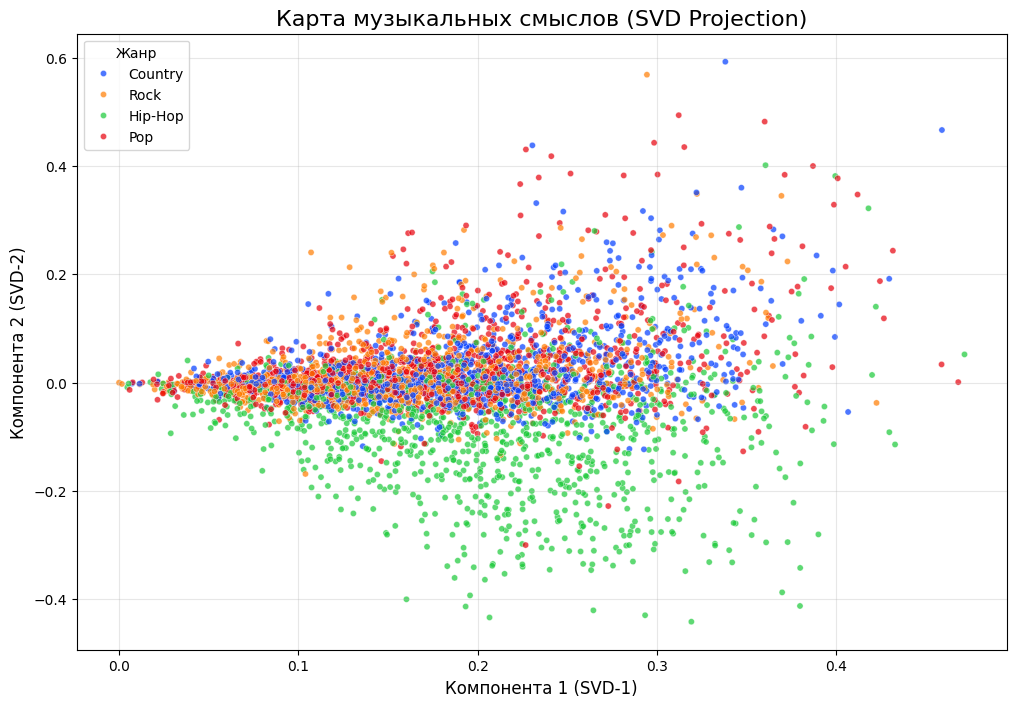

In [ ]:
# 1. Создаем удобную табличку для рисования
# Берем координаты из SVD
plot_data = pd.DataFrame(X_svd, columns=['x', 'y'])

# Добавляем к ней жанры из твоего df (важно, чтобы индексы совпадали!)
# Так как мы не меняли порядок строк с момента создания матрицы, всё совпадет
plot_data['genre'] = df['main_genre'].values

# 2. Рисуем
plt.figure(figsize=(12, 8))

# hue='genre' — раскрасить точки в зависимости от жанра
sns.scatterplot(
    data=plot_data,
    x='x',
    y='y',
    hue='genre',
    alpha=0.7,      # Прозрачность точек
    palette='bright', # Яркие цвета
    s=20            # Размер точек
)

plt.title('Карта музыкальных смыслов (SVD Projection)', fontsize=16)
plt.xlabel('Компонента 1 (SVD-1)', fontsize=12)
plt.ylabel('Компонента 2 (SVD-2)', fontsize=12)
plt.legend(title='Жанр')
plt.grid(True, alpha=0.3)
plt.show()

При двух компонентах можно различить, что Hip-Hop сильнее всех отличается и делает его сильным независимым жанром в векторном пространстве Bag of words

Изобразим в 3D svd с 3мя компонентами

In [ ]:
# 1. Запускаем SVD с 3 компонентами
svd_3d = TruncatedSVD(n_components=3, random_state=52)
X_svd_3d = svd_3d.fit_transform(X) # X берем из прошлого шага

print(f"Размерность 3D матрицы: {X_svd_3d.shape}")

# 2. Собираем датафрейм для графика
df_3d = pd.DataFrame(X_svd_3d, columns=['x', 'y', 'z'])
df_3d['genre'] = df['main_genre'].values

# Добавим еще название песни
# чтобы при наведении мышки видеть, что это за песня
df_3d['snippet'] = df['name_song'].str[:100]

Размерность 3D матрицы: (4400, 3)


In [ ]:
df_3d.head()

,x,y,z,genre,snippet
0,0.130355,-0.020217,-0.058961,Country,False Accuser's Lament
1,0.131480,0.027702,-0.003660,Rock,Wait For The Wintertime
2,0.096400,-0.023277,-0.018829,Rock,Italian Leather Sofa
3,0.115711,0.000890,-0.040008,Country,She's a Butterfly
4,0.097127,0.012868,-0.083837,Hip-Hop,Burning Inside


In [ ]:
fig = px.scatter_3d(
    df_3d,
    x='x',
    y='y',
    z='z',
    color='genre',           # Раскраска по жанрам
    hover_data=['snippet'],  # Что показывать при наведении
    opacity=0.6,             # Прозрачность
    size_max=5,              # Размер точек
    title='3D Карта музыкальных жанров'
)

# Настройка внешнего вида (делаем точки поменьше)
fig.update_traces(marker=dict(size=3))

fig.show()

На графике 3D с 3мя компонентами можно точно сказать, что жанр hip-hop выделяется, но Pop и Rock, County очень рядом между собой


In [ ]:
# 1. Оставляем только нужные 3 жанра
target_genres = ['Hip-Hop', 'Rock', 'Pop']
df_subset = df[df['main_genre'].isin(target_genres)].copy()

print(f"Новый размер данных: {df_subset.shape}")
# Должно быть 3300 строк (3 * 1100)

# 2. Строим TF-IDF заново (чтобы забыть слова типа 'cowboy', если они были только в Кантри)
tfidf_subset = TfidfVectorizer(max_features=5000, stop_words='english', min_df=3)
X_subset = tfidf_subset.fit_transform(df_subset['final_text'])

# 3. Считаем SVD заново
svd_subset = TruncatedSVD(n_components=3, random_state=42)
X_svd_subset = svd_subset.fit_transform(X_subset)

# 4. Готовим данные для графика
df_3d_subset = pd.DataFrame(X_svd_subset, columns=['x', 'y', 'z'])
df_3d_subset['genre'] = df_subset['main_genre'].values
df_3d_subset['snippet'] = df_subset['final_text'].str[:100]



Новый размер данных: (3300, 7)


In [ ]:
fig = px.scatter_3d(
    df_3d_subset,
    x='x',
    y='y',
    z='z',
    color='genre',
    hover_data=['snippet'],
    opacity=0.6,
    size_max=5,
    # Зададим конкретные цвета, чтобы было контрастно
    color_discrete_map={'Hip-Hop': 'green', 'Rock': 'blue', 'Pop': 'red'},
    title='Битва титанов: Rock vs Pop vs Rap'
)

fig.update_traces(marker=dict(size=3))
fig.show()

Интерпретация: жанр хип-хоп сильнее и лучшее различается в векторном пространстве Bag of words

Часть 2: Векторная Арифметика (Cosine Similarity) - "Векторная схожесть двух объектов"

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 1. Создаем SVD на 50 измерений для точности
svd_math = TruncatedSVD(n_components=50, random_state=42)
matrix_math = svd_math.fit_transform(X) # Используем X из TF-IDF шага

print(f"Матрица для математики готова: {matrix_math.shape}")
# Должно быть (4400, 50)

Матрица для математики готова: (4400, 50)


In [ ]:
# Функция для поиска индекса песни по части названия
def find_song_index(query, df):
    # Ищем совпадение в названии песни или артисте (регистронезависимо)
    mask = df['name_song'].str.contains(query, case=False, na=False) | \
           df['artist_name'].str.contains(query, case=False, na=False)

    results = df[mask]

    if results.empty:
        print(f"Песня '{query}' не найдена :(")
        return None

    # Возвращаем первый найденный результат (индекс и инфо)
    idx = results.index[0] # Это оригинальный индекс pandas

    # ВАЖНО: Нам нужен порядковый номер строки (0, 1, 2...),
    # так как в матрице строки идут по порядку, а в df индекс может быть перепутан
    # reset_index мы делали, так что если df_balanced сброшен, то loc совпадает с iloc

    # Выводим найденное для проверки
    found_song = results.iloc[0]
    print(f"Найдена: {found_song['artist_name']} - {found_song['name_song']} (Жанр: {found_song['main_genre']})")

    # Возвращаем порядковый номер (iloc index)
    row_number = df.index.get_loc(idx)
    return row_number

In [ ]:
# Обучаем "поисковик" по нашей матрице
nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(matrix_math)

def musical_alchemy(song1_query, song2_query, df, matrix):
    # 1. Ищем индексы песен
    idx1 = find_song_index(song1_query, df)
    idx2 = find_song_index(song2_query, df)

    if idx1 is None or idx2 is None:
        return

    # 2. Достаем их векторы
    vec1 = matrix[idx1]
    vec2 = matrix[idx2]

    # 3. МАГИЯ: Складываем и делим на 2 (среднее арифметическое)
    # Это создает новую точку ровно посередине между ними
    mix_vec = (vec1 + vec2) / 2

    # Надо изменить форму вектора для sklearn (1, 50)
    mix_vec = mix_vec.reshape(1, -1)

    # 4. Ищем, какая песня ближе всего к этой новой точке
    distances, indices = nn.kneighbors(mix_vec)

    print("\n🧪 РЕЗУЛЬТАТ АЛХИМИИ:")
    print(f"{df.iloc[idx1]['artist_name']} + {df.iloc[idx2]['artist_name']} = ...\n")

    # Выводим топ-3 похожих (пропускаем исходные песни, если они вдруг попались)
    input_indices = [idx1, idx2]
    found_count = 0

    for i in range(len(indices[0])):
        result_idx = indices[0][i]
        dist = distances[0][i]

        # Не показываем сами исходные песни в результате
        if result_idx not in input_indices:
            song = df.iloc[result_idx]
            print(f"👉 {song['artist_name']} - {song['name_song']} ({song['main_genre']})")
            print(f"   (Цитата: {song['final_text'][:60]}...)")
            print(f"   Дистанция: {dist:.4f}\n")
            found_count += 1
            if found_count >= 1: break # Показываем только 1 самый лучший матч

In [ ]:
# Пример запуска (замени названия на те, что есть у тебя)
musical_alchemy("Eminem", "Britney", df, matrix_math)

Найдена: Eminem - Role Model (Жанр: Hip-Hop)
Найдена: Britney Spears - Touch of My Hand (Жанр: Pop)

🧪 РЕЗУЛЬТАТ АЛХИМИИ:
Eminem + Britney Spears = ...

👉 Shura - White Light - Radio Edit / 2015 Version (Pop)
   (Цитата: different like another planet like take fly alien spaceship ...)
   Дистанция: 0.2588



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_alchemy(song1_query, song2_query, df, matrix_math, matrix_2d):
    # 1. Получаем индексы
    idx1, idx2, idx3 = get_alchemy_indices(song1_query, song2_query, df, matrix_math)

    if idx1 is None: return

    # 2. Достаем 2D координаты для графика
    # matrix_2d — это то, что мы получили в самом начале (X_svd)
    p1 = matrix_2d[idx1] # Родитель 1
    p2 = matrix_2d[idx2] # Родитель 2
    p3 = matrix_2d[idx3] # Ребенок

    # Имена для подписей
    name1 = f"{df.iloc[idx1]['artist_name']} ({df.iloc[idx1]['main_genre']})"
    name2 = f"{df.iloc[idx2]['artist_name']} ({df.iloc[idx2]['main_genre']})"
    name3 = f"{df.iloc[idx3]['artist_name']} ({df.iloc[idx3]['main_genre']})"

    # --- РИСОВАНИЕ ---
    plt.figure(figsize=(12, 8))

    # A. Фон (все остальные песни)
    plt.scatter(matrix_2d[:, 0], matrix_2d[:, 1], c='lightgrey', alpha=0.3, s=10, label='Все песни')

    # B. Линия связи (пунктир между родителями)
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k--', alpha=0.5, label='Вектор смешивания')

    # C. Точки родителей
    plt.scatter(p1[0], p1[1], c='blue', s=150, edgecolors='black', label='Родитель 1')
    plt.scatter(p2[0], p2[1], c='red', s=150, edgecolors='black', label='Родитель 2')

    # D. Точка ребенка (Звездочка)
    plt.scatter(p3[0], p3[1], c='gold', s=250, marker='*', edgecolors='black', label='Результат (Ребенок)')

    # E. Подписи текстом (с небольшим смещением, чтобы не перекрывать точки)
    plt.text(p1[0], p1[1]+0.01, name1, fontsize=11, fontweight='bold', color='darkblue')
    plt.text(p2[0], p2[1]+0.01, name2, fontsize=11, fontweight='bold', color='darkred')
    plt.text(p3[0], p3[1]-0.02, name3, fontsize=12, fontweight='bold', color='black', backgroundcolor='white')

    plt.title(f"Музыкальная Алгебра: {name1} + {name2}", fontsize=15)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:


# Пример 1: Эминем + Бритни Спирс
# visualize_alchemy("Eminem", "Britney", df, matrix_math, X_svd)

# Пример 2: Nirvana + 50 Cent
 visualize_alchemy("Nirvana", "50 Cent", df, matrix_math, X_svd)

IndentationError: unexpected indent (ipython-input-1740226948.py, line 5)

Интерпретация и интуиция потом объяснить

Глава 3:TextRank (Eigenvector Centrality) - "Выжимка песни через собственные числа"


описание и смысл потом


In [ ]:
!pip install networkx

In [ ]:
# Найдем индекс какой-нибудь длинной песни
song_idx = find_song_index("False Accuser's Lament", df)

# Если Rap God нет, давай возьмем просто самую длинную песню в датасете
if song_idx is None:
    # Сортируем по длине текста и берем топ-1
    longest_song_idx = df['final_text'].str.len().sort_values(ascending=False).index[0]
    # Переводим в iloc индекс
    song_idx = df.index.get_loc(longest_song_idx)

target_text = df.iloc[song_idx]['final_text']
song_title = df.iloc[song_idx]['name_song']
print(f"\nБудем препарировать песню: {song_title}")
print(f"Длина текста (слов): {len(target_text.split())}")

Найдена: Jason Boland & The Stragglers - False Accuser's Lament (Жанр: Country)

Будем препарировать песню: False Accuser's Lament
Длина текста (слов): 150


Бежим по тексту "окошком" (sliding window).
Если слова рядом — связываем их.
Считаем Eigenvector Centrality (собственный вектор матрицы смежности).


In [ ]:
import networkx as nx

def extract_keywords_textrank(text, window_size=3, top_n=10):
    # 1. Разбиваем текст на слова
    words = text.split()

    # 2. Строим граф
    # Узлы - это слова. Ребра - если слова встретились рядом в окне.
    graph = nx.Graph()

    # Добавляем узлы
    graph.add_nodes_from(set(words))

    # Добавляем связи (проходим скользящим окном)
    for i in range(len(words) - window_size + 1):
        window = words[i : i + window_size]
        # Внутри окна связываем каждый с каждым (кроме самого себя)
        for w1 in window:
            for w2 in window:
                if w1 != w2:
                    graph.add_edge(w1, w2)

    # 3. МАГИЯ: Считаем PageRank (это и есть поиск собственного вектора)
    # scores - это словарь {слово: важность}
    scores = nx.pagerank(graph)

    # 4. Сортируем и берем топ
    ranked_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranked_words[:top_n], graph

# Запускаем
top_keywords, G = extract_keywords_textrank(target_text)

print(f"\n🔑 Ключевые слова (TextRank) для '{song_title}':")
for i, (word, score) in enumerate(top_keywords):
    print(f"{i+1}. {word} (Важность: {score:.4f})")


🔑 Ключевые слова (TextRank) для 'False Accuser's Lament':
1. see (Важность: 0.0294)
2. lie (Важность: 0.0237)
3. let (Важность: 0.0184)
4. banker (Важность: 0.0182)
5. man (Важность: 0.0176)
6. shoot (Важность: 0.0175)
7. could (Важность: 0.0174)
8. nightly (Важность: 0.0173)
9. alone (Важность: 0.0160)
10. never (Важность: 0.0159)


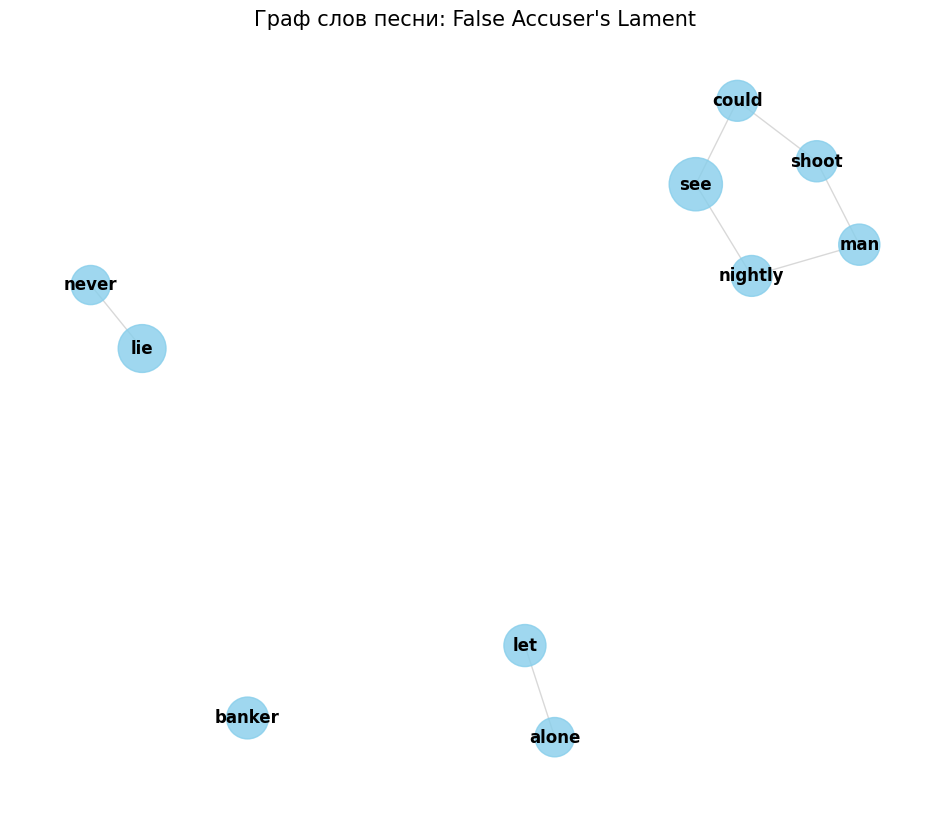

In [ ]:
def plot_text_graph(graph, ranked_words, title):
    # Берем только топ-30 слов для рисунка
    top_30_words = [w[0] for w in ranked_words[:30]]
    subgraph = graph.subgraph(top_30_words)

    plt.figure(figsize=(12, 10))

    # Layout - алгоритм расстановки точек, чтобы было красиво (spring - как пружинки)
    pos = nx.spring_layout(subgraph, k=0.5, seed=42)

    # Рисуем узлы
    # Размер узла зависит от его важности (PageRank score)
    # Нам нужно достать скоры обратно из списка
    scores_dict = dict(ranked_words)
    node_sizes = [scores_dict[n] * 50000 for n in subgraph.nodes()] # Умножаем для масштаба

    nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)

    # Рисуем связи
    nx.draw_networkx_edges(subgraph, pos, alpha=0.3, edge_color='gray')

    # Рисуем слова
    nx.draw_networkx_labels(subgraph, pos, font_size=12, font_weight='bold')

    plt.title(f"Граф слов песни: {title}", fontsize=15)
    plt.axis('off') # Убираем оси координат
    plt.show()

# Рисуем
plot_text_graph(G, top_keywords, song_title)

Итоги, показать список рекомендуемых, посоветовать но основе песню, визуализация, можно не одну песню, а несколько

тогда более детально графики, рекомендации
пересечение посмотреть 3х алгоритмов, либо комбинировать модели, скомбинировать output
выводы
какой метод для чего, как и блокнот

прикрутить типо как рекомендации фильмов
посмотреть на современные алгоритмы рекомендашек, объяснить где мои методы используются
впринципе исчерпывающее. бля, отмена для рекомендаций по фильмам



